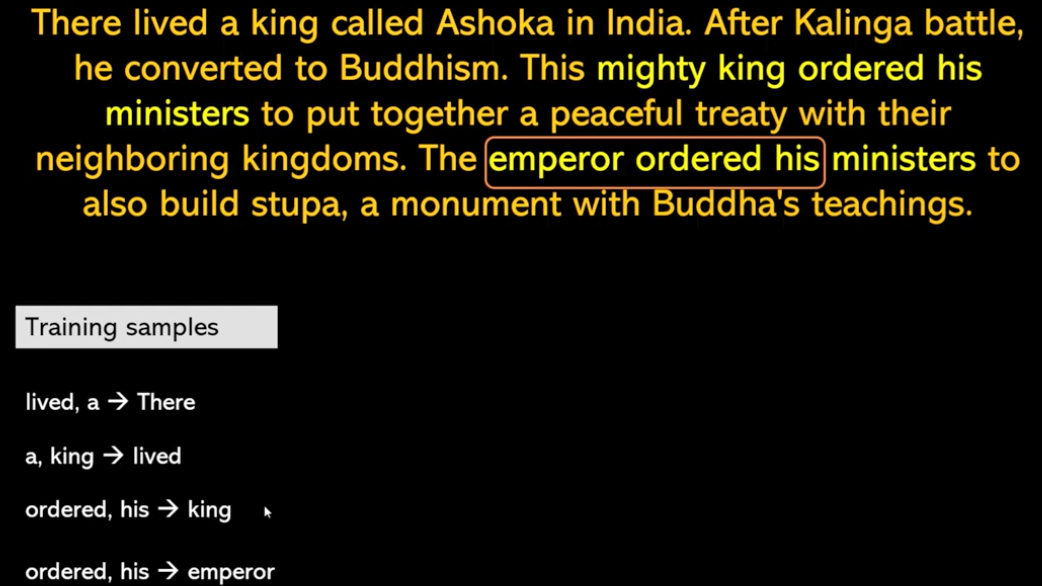

In [1]:
# !pip install gensim
# !pip install python-Levenshtein

In [2]:
import gensim
import pandas as pd

### Reading and Exploring the Dataset
The dataset we are using here is a subset of Amazon reviews from the Cell Phones & Accessories category. The data is stored as a JSON file and can be read using pandas.

Link to the Dataset: http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Cell_Phones_and_Accessories_5.json.gz

In [3]:
df = pd.read_json("Cell_Phones_and_Accessories_5.json", lines=True)
df

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A30TL5EWN6DFXT,120401325X,christina,"[0, 0]",They look good and stick good! I just don't li...,4,Looks Good,1400630400,"05 21, 2014"
1,ASY55RVNIL0UD,120401325X,emily l.,"[0, 0]",These stickers work like the review says they ...,5,Really great product.,1389657600,"01 14, 2014"
2,A2TMXE2AFO7ONB,120401325X,Erica,"[0, 0]",These are awesome and make my phone look so st...,5,LOVE LOVE LOVE,1403740800,"06 26, 2014"
3,AWJ0WZQYMYFQ4,120401325X,JM,"[4, 4]",Item arrived in great time and was in perfect ...,4,Cute!,1382313600,"10 21, 2013"
4,ATX7CZYFXI1KW,120401325X,patrice m rogoza,"[2, 3]","awesome! stays on, and looks great. can be use...",5,leopard home button sticker for iphone 4s,1359849600,"02 3, 2013"
...,...,...,...,...,...,...,...,...,...
194434,A1YMNTFLNDYQ1F,B00LORXVUE,eyeused2loveher,"[0, 0]",Works great just like my original one. I reall...,5,This works just perfect!,1405900800,"07 21, 2014"
194435,A15TX8B2L8B20S,B00LORXVUE,Jon Davidson,"[0, 0]",Great product. Great packaging. High quality a...,5,Great replacement cable. Apple certified,1405900800,"07 21, 2014"
194436,A3JI7QRZO1QG8X,B00LORXVUE,Joyce M. Davidson,"[0, 0]","This is a great cable, just as good as the mor...",5,Real quality,1405900800,"07 21, 2014"
194437,A1NHB2VC68YQNM,B00LORXVUE,Nurse Farrugia,"[0, 0]",I really like it becasue it works well with my...,5,I really like it becasue it works well with my...,1405814400,"07 20, 2014"


In [4]:
df.shape

(194439, 9)

### Simple Preprocessing & Tokenization
The first thing to do for any data science task is to clean the data.
For NLP, we apply various processing like converting all the words to lower case, trimming spaces, removing punctuations. 
This is something we will do over here too.

Additionally, we can also remove stop words like 'and', 'or', 'is', 'the', 'a', 'an' and convert words to their root forms like 'running' to 'run'.

In [5]:
gensim.utils.simple_preprocess("I am running and ...")

['am', 'running', 'and']

In [6]:
review_text = df.reviewText.apply(gensim.utils.simple_preprocess)

In [7]:
review_text

0         [they, look, good, and, stick, good, just, don...
1         [these, stickers, work, like, the, review, say...
2         [these, are, awesome, and, make, my, phone, lo...
3         [item, arrived, in, great, time, and, was, in,...
4         [awesome, stays, on, and, looks, great, can, b...
                                ...                        
194434    [works, great, just, like, my, original, one, ...
194435    [great, product, great, packaging, high, quali...
194436    [this, is, great, cable, just, as, good, as, t...
194437    [really, like, it, becasue, it, works, well, w...
194438    [product, as, described, have, wasted, lot, of...
Name: reviewText, Length: 194439, dtype: object

In [8]:
df.reviewText.loc[0]

"They look good and stick good! I just don't like the rounded shape because I was always bumping it and Siri kept popping up and it was irritating. I just won't buy a product like this again"

In [9]:
review_text.loc[0][:5]

['they', 'look', 'good', 'and', 'stick']

### Training the Word2Vec Model

#### Initialize the model

In [10]:
model = gensim.models.Word2Vec(
    window=10,
    min_count=2,
    workers=4,
)

#### Build Vocabulary

In [11]:
model.build_vocab(review_text, progress_per=1000)

#### Train the Word2Vec Model

In [12]:
model.train(review_text, total_examples=model.corpus_count, epochs=model.epochs)

(61505936, 83868975)

### Save the Model

Save the model so that it can be reused in other applications

In [13]:
model.save("./word2vec-amazon-cell-accessories-reviews-short.model")

### Finding Similar Words and Similarity between words

In [14]:
model.wv.most_similar("bad")

[('terrible', 0.6753890514373779),
 ('shabby', 0.6621032357215881),
 ('good', 0.5924431085586548),
 ('horrible', 0.5739178657531738),
 ('legit', 0.5357282161712646),
 ('awful', 0.5238867998123169),
 ('okay', 0.5238810777664185),
 ('lame', 0.5223859548568726),
 ('crappy', 0.5177780389785767),
 ('sad', 0.5171573758125305)]

In [15]:
model.wv.similarity(w1="cheap", w2="inexpensive")

np.float32(0.5356508)

In [16]:
model.wv.similarity(w1="great", w2="good")

np.float32(0.7812107)